In [ ]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import emcee
from multiprocessing import Pool
import time
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# =========================
# Loading CC data
# =========================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc   = df_cc["z_cc"].to_numpy(float)
H_obs  = df_cc["H_cc"].to_numpy(float)
H_err  = df_cc["H_cc_err"].to_numpy(float)


# ========================================================
# Loading SNe Ia data
# ========================================================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"
df_sne = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))

mask = df_sne["zCMB"].values > 0.01
df_cut = df_sne[mask].reset_index(drop=True)
Cov_sne = Cov_sne_full[mask, :][:, mask]
z_sne = df_cut["zCMB"].values
mB_obs = df_cut["m_b_corr"].values
Cinv_sne = np.linalg.inv(Cov_sne)

# ========================================================
# Loading DESI BAO DR2 data
# ========================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"
df_bao = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])

z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values
cov_bao = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,       H0_max       = 50.0,   90.0
Om0_min,      Om0_max      = 0.1,    0.6
MB_min,       MB_max       = -19.8,  -18.6
w0_min,       w0_max       = -3.0,   1.0
wa_min,       wa_max       = -3.0,   2.0

# Gaussian priors
mu_Ob, sigma_Ob = 0.0495, 0.0025
mu_MB, sigma_MB = -19.24, 0.04

# Physical constants
c_kms = 299792.458 

# Astrophysical/cosmological parameters
Neff = 3.046

# ====================================================
# Redshift / scale-factor grids
# ====================================================

zi, zf = 0.0, 2.5
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)

In [4]:
# ==============================
# Hubble functions
# ==============================

def E_CPL(z, Om0, w0, wa):
    Om = Om0 * (1 + z)**3

    Ode0 = 1 - Om0
    power = 3*(1 + w0 + wa)
    fde = np.exp(-3*wa*z/(1+z))
    Ode = Ode0 * (1 + z)**power * fde
    return np.sqrt(Om + Ode)

def H_CPL(z, H0, Om0, w0, wa):
    return H0 * E_CPL(z, Om0, w0, wa)


# ========================================================
# Luminosity distance
# ========================================================

def dL_CPL(z, H0, Om0, w0, wa):
    prefactor  = c_kms * (1.0 + z)
    H_grid     = H_CPL(z_grid, H0, Om0, w0, wa)
    integrand  = 1.0 / H_grid
    integral   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    integral_z = np.interp(z, z_grid, integral)
    return prefactor * integral_z


# ========================================================
# Comoving distance
# ========================================================

def comoving_dist(z, H0, Om0, w0, wa):
    E_vals = E_CPL(z_grid, Om0, w0, wa)
    integrand = 1.0 / E_vals
    integral = np.empty_like(z_grid)
    integral[0] = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z = np.interp(z, z_grid, integral)
    return (c_kms / H0) * I_z

In [5]:
# ========================================================
# Apparent magnitude
# ========================================================

def mB_CPL(z, H0, Om0, MB, w0, wa):
    dL = dL_CPL(z, H0, Om0, w0, wa)
    mu = 5.0 * np.log10(dL) + 25.0 
    return mu + MB


# ====================================================
# Theoretical BAO vector
# ====================================================

def d_CPL(z_arr, q_arr, H0, Om0, Ob, w0, wa):
    h2 = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd = 147.05 * ((Obh2/0.02236)**-0.13) \
                  * ((Omh2/0.1432)**-0.23) \
                  * ((Neff/3.04)**-0.1)
    dC = comoving_dist(z_arr, H0, Om0, w0, wa)
    H_z = H_CPL(z_arr, H0, Om0, w0, wa)
    dm = dC / rd
    dh = (c_kms / H_z) / rd
    dv = (z_arr * dm**2 * dh)**(1/3)
    d_bao = np.empty_like(z_arr)
    mask_dv = np.array(["dv" in q for q in q_arr])
    mask_dm = np.array(["dm" in q for q in q_arr])
    mask_dh = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao

In [6]:
# ====================================================
# CC + SNe + BAO Likelihood
# ====================================================

# Log-priors
def lnprior_cc_sne_bao(theta):
    H0, Om0, Ob, MB, w0, wa = theta
    if not (H0_min       <= H0         <= H0_max):        return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):       return -np.inf
    if not (0.0          <  Ob         < Om0):            return -np.inf
    if not (MB_min       <= MB         <= MB_max):        return -np.inf
    if not (w0_min       <= w0         <= w0_max):        return -np.inf
    if not (wa_min       <= wa         <= wa_max):        return -np.inf
    lp_Ob = -0.5 * ((Ob - mu_Ob) / sigma_Ob)**2
    lp_MB = -0.5 * ((MB - mu_MB) / sigma_MB)**2
    return lp_Ob + lp_MB


# Log-likelihood
def lnlike_cc_sne_bao(theta,
                      z_cc, H_obs, H_err,
                      z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao):
    H0, Om0, Ob, MB, w0, wa = theta
    # -------------------------------------------------
    # CC part
    # -------------------------------------------------
    H_model = H_CPL(z_cc, H0, Om0, w0, wa)
    chi2_cc = np.sum(((H_obs - H_model) / H_err)**2) 
    lnL_cc  = -0.5 * chi2_cc
    # -------------------------------------------------
    # SNe part
    # -------------------------------------------------
    mB_model  = mB_CPL(z_sne, H0, Om0, MB, w0, wa)
    resid_sne = mB_obs - mB_model
    chi2_sne  = resid_sne @ Cinv_sne @ resid_sne
    lnL_sne   = -0.5 * chi2_sne
    # -------------------------------------------------
    # BAO part
    # -------------------------------------------------
    d_model   = d_CPL(z_bao, q_bao, H0, Om0, Ob, w0, wa)
    resid_bao = d_obs - d_model
    chi2_bao  = resid_bao @ Cinv_bao @ resid_bao
    lnL_bao   =  -0.5 * chi2_bao
    return lnL_cc + lnL_sne + lnL_bao


# Log-posterior
def lnprob_cc_sne_bao(theta,
                      z_cc, H_obs, H_err,
                      z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao):
    lp = lnprior_cc_sne_bao(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = lnlike_cc_sne_bao(theta,
                           z_cc, H_obs, H_err,
                           z_sne, mB_obs, Cinv_sne,
                           z_bao, d_obs, q_bao, Cinv_bao)
    return lp + ll


# ====================================================
# Quick test
# ====================================================

theta_test = [70, 0.3, 0.0494, -19.24, -1.0, 0.0]
print("CC + SNe + BAO log-posterior =",
       lnprob_cc_sne_bao(theta_test, 
                         z_cc, H_obs, H_err,
                         z_sne, mB_obs, Cinv_sne,
                         z_bao, d_obs, q_bao, Cinv_bao))

CC + SNe + BAO log-posterior = -1187.1196053373794


In [7]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 6
nwalkers = 48
nsteps   = 20000

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, -1.0, 0.0])
scales = np.array([ 2.0, 0.02, 0.001,   0.02,  0.1, 0.2])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_sne_bao(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (CC + SNe + BAO) ===")
t_mcmc = time.time()

# with Pool(processes=nwalkers) as pool:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc_sne_bao,
    args=(z_cc, H_obs, H_err,
            z_sne, mB_obs, Cinv_sne,
            z_bao, d_obs, q_bao, Cinv_bao),
    #    pool=pool
)
sampler.run_mcmc(p0, nsteps, progress=True)

print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (CC + SNe + BAO) ===


100%|██████████| 20000/20000 [03:59<00:00, 83.50it/s]


MCMC completed in 4.0 min


In [8]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.514
Acceptance status: ACCEPTABLE

Max autocorrelation time τ_max = 71.43
Chain length / τ_max           = 280.0
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 214 steps (1.1%)
Thin (τ_max/2)                 = 35
Minimum N_eff                  = 13295
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [9]:
# ====================================================
# Chain extraction
# ====================================================

# flat_log    = sampler.get_chain(discard=nburn, thin=nthin, flat=True)       # Apply thin
flat_log      = sampler.get_chain(discard=nburn, flat=True)                   # No thin
flat_samples  = flat_log.copy()

# Save flat samples
fname = "flat_samples_CPL_cc_sne_bao.npy"
np.save(fname, flat_samples)

print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used                : {nburn} steps")
print(f"Saved to                    : {fname}")


Final independent samples : 949728
Burn-in used                : 214 steps
Saved to                    : flat_samples_CPL_cc_sne_bao.npy


Removed no burn in


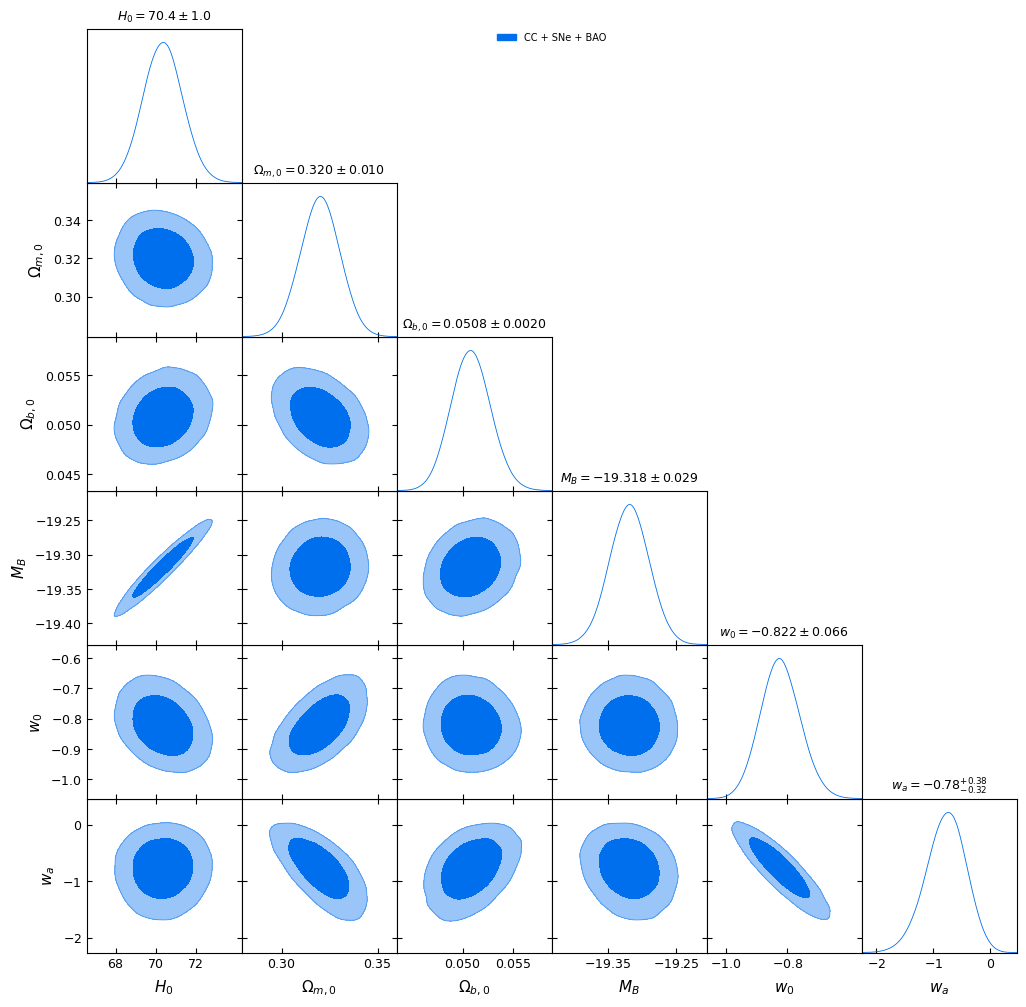

In [12]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "w0", "wa"]
param_labels = [r"H_0", r"\Omega_{m,0}", r"\Omega_{b,0}", r"M_B", r"w_0", r"w_a"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)
samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 12
g.settings.lab_fontsize        = 14
g.settings.legend_fontsize     = 10
g.settings.linewidth_contour   = 1.2
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3
g.triangle_plot(samples_gd, filled=True,
                legend_labels=["CC + SNe + BAO"],
                title_limit=1)

figname = "Corner_CPL_cc_sne_bao.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# ====================================================
# Marginalized statistics
# ====================================================

marge = samples_gd.getMargeStats()
print("\n" + "="*60)
print(f"{'FINAL INFERENCE RESULTS (CPL: CC + SNe + BAO)':^60}")
print("="*60)

for name in ["H0", "Om0", "Ob", "MB", "w0", "wa"]:
    stats = marge.parWithName(name)
    print(f"\n  {name}:")
    print(f"    Mean ± 1σ : {stats.mean:.4f} ± {stats.err:.4f}")
    print(f"    95% CL    : [{stats.limits[1].lower:.4f}, "
          f"{stats.limits[1].upper:.4f}]")


       FINAL INFERENCE RESULTS (CPL: CC + SNe + BAO)        

  H0:
    Mean ± 1σ : 70.3540 ± 1.0007
    95% CL    : [68.4094, 72.3381]

  Om0:
    Mean ± 1σ : 0.3200 ± 0.0103
    95% CL    : [0.2996, 0.3401]

  Ob:
    Mean ± 1σ : 0.0508 ± 0.0020
    95% CL    : [0.0470, 0.0548]

  MB:
    Mean ± 1σ : -19.3184 ± 0.0288
    95% CL    : [-19.3752, -19.2619]

  w0:
    Mean ± 1σ : -0.8218 ± 0.0656
    95% CL    : [-0.9467, -0.6890]

  wa:
    Mean ± 1σ : -0.7839 ± 0.3539
    95% CL    : [-1.5171, -0.1300]


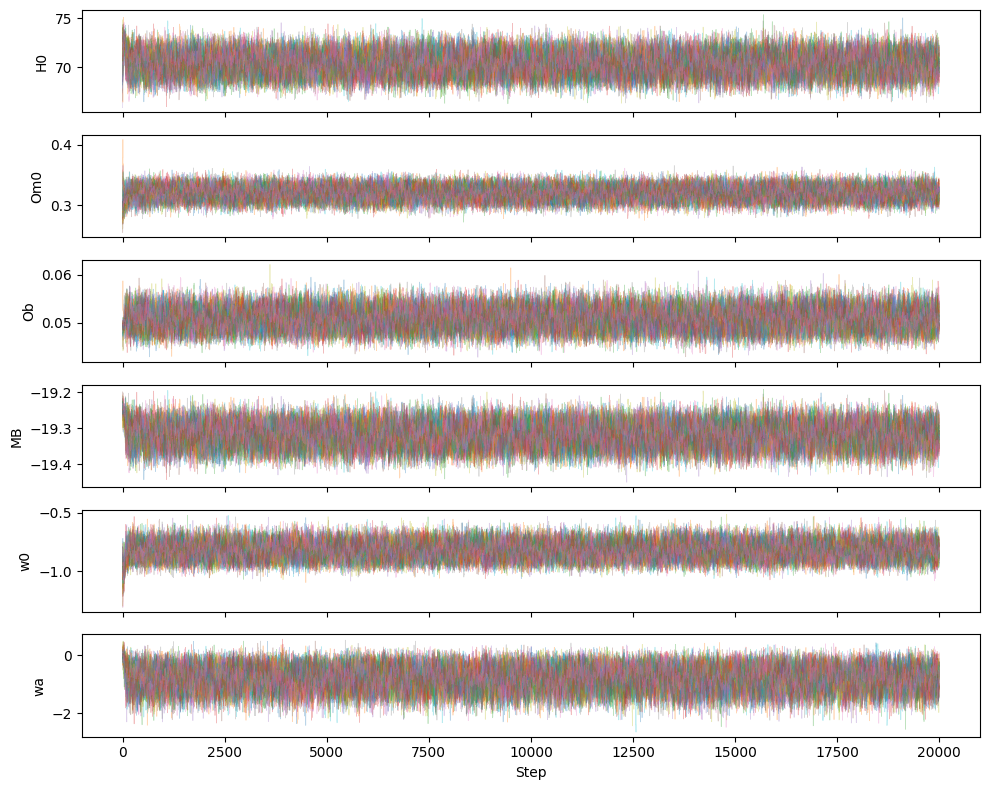

In [18]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()

fig, axes = plt.subplots(6, figsize=(10, 8), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "MB", "w0", "wa"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()